This report identifies two issues in the cue-similarity analysis reported in `Semantic Analysis: 2x2x2 comparison.R`:

1. **Incomplete `background_map`.**  The map (lines 82–93) was built from background codes observed in the negative film's Excel files. Six of the eleven neutral film cue codes use a `_1` scene suffix that has no entry, so they pass through `dplyr::recode()` unchanged and fail the `cue %in% as.character(1:11)` match check. This silently excludes 757 neutral memories (34.6% of all neutral memory events) from ever being counted as matches. Adding the six missing entries reverses the emotion main effect: neutral match percentage rises from 18.8% to 47.7%, exceeding negative (36.7%).

2. **Variable-denominator metric.**  The match percentage is computed as `matches / total_memories` per participant. The denominator includes every memory event — including those attributed to foils, which can never match a cue. Because total memory counts vary systematically across conditions (voluntary sessions produce more memories than involuntary sessions), the metric conflates recall volume with cue effectiveness. A fixed-denominator alternative (cue hits / 22 cue presentations) removes this confound and shows that the intentionality main effect is non-significant.

The report walks through five steps:

1. **Replication** — we reproduce the published match counts and boxplot figure in Python, working from the pipeline's own CSV output, to confirm we faithfully represent the original analysis.
2. **Diagnosis** — we inspect the `cue_background` field and trace the six missing entries in the map, showing exactly which neutral memories are affected and why.
3. **Correction** — we add the six missing entries and recompute, showing that the emotion main effect reverses.
4. **Metric comparison** — we show that the variable denominator inflates the intentionality effect, and that a fixed-denominator metric eliminates it.
5. **Convergent evidence** — three analyses of the same dataset agree on the corrected emotion direction.

All analyses are fully reproducible. The Python code behind each figure and test is available in the [Article Notebook](index-preview.html).

In [1]:
#| code-summary: "Setup and imports"
import csv
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from jaxcmr.helpers import find_project_root

ROOT = Path(find_project_root())
CSV_PATH = (
    ROOT
    / "projects/selective_interference/Cue-Similarity Check"
    / "Analysis Code/Inferential Stats"
    / "all_memories_with_reaction_time_and_match_status.csv"
)


## Context

The cue-similarity analysis attributes each recalled memory to the most recent background image (film cue or foil) and then compares the memory's embedding-assigned clip against that background. A memory counts as a "match" when `cue_background == assigned_clip` and both values are in `{"1", "2", ..., "11"}` — i.e., both refer to a valid film clip rather than a foil or external detail. The per-participant match percentage is `mean(match) × 100` across all of that participant's memory events, and the paper reports a large emotion main effect: F(1,229) = 38.27, p < .001, η² = .13, with negative film participants showing higher match percentages than neutral.

Everything below uses the analysis pipeline's own output CSV — no re-running of the R script or embedding model is required.

In [2]:
#| code-summary: "Load CSV data"
def load_memories(path):
    """Load the per-memory output CSV into a list of dicts."""
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
    return rows

rows = load_memories(CSV_PATH)

# Clean up the condition field (has embedded newlines in the CSV)
for r in rows:
    r["condition"] = r["condition"].replace("\n", " ").strip()

# Basic stats
conditions = Counter(r["condition"] for r in rows)
print(f"Total memory events: {len(rows)}")
print(f"Columns: {list(rows[0].keys())}")
print("\nMemories per condition group:")
for cond, n in sorted(conditions.items()):
    print(f"  {cond}: {n}")

Total memory events: 4101
Columns: ['', 'Participant_Number', 'memory_description', 'cue_background', 'reaction_sum', 'assigned_clip', 'condition', 'match_status']

Memories per condition group:
  Negative Film No Intervention, Involuntary: 362
  Negative Film No Intervention, Voluntary: 574
  Negative Film Visuo-Spatial, Involuntary: 429
  Negative Film Visuo-Spatial, Voluntary: 551
  Neutral Film No Intervention, Involuntary: 479
  Neutral Film No Intervention, Voluntary: 674
  Neutral Film Visuo-Spatial, Involuntary: 495
  Neutral Film Visuo-Spatial, Voluntary: 537


## Replicating the published match counts

Before investigating anything, we first confirm that we can exactly reproduce the published numbers from the pipeline's output data. This establishes that any discrepancy we later identify is genuinely in the pipeline, not an artefact of our re-analysis.

The R function `calculate_cue_memory_similarity()` (line 374 of the 2×2×2 script) computes a per-participant match percentage as follows: for every memory event, `match = 1` if `cue_background == assigned_clip` and both are in `{"1", ..., "11"}`; otherwise `match = 0`. The participant's percentage is `mean(match) × 100`. Participants with fewer than 4 total memories are excluded (line 34 of `ANOVA_MATCH_PERCENTAGE.R`). We replicate this logic in Python.


In [3]:
#| code-summary: "Compute match percentages (replicating R pipeline)"
VALID_CLIPS = {str(i) for i in range(1, 12)}


def compute_match_percentages(rows, fix_map=None):
    """Replicate the R match-percentage calculation.

    Parameters
    ----------
    rows : list[dict]
        Per-memory records from the CSV.
    fix_map : dict or None
        If provided, remap cue_background values before the match check.

    Returns
    -------
    dict
        {condition: {participant: {"matched": int, "total": int}}}
    """
    groups = defaultdict(lambda: defaultdict(lambda: {"matched": 0, "total": 0}))
    for r in rows:
        cond = r["condition"]
        pid = int(r["Participant_Number"])
        bg = r["cue_background"].strip()
        assigned = r["assigned_clip"].strip()

        if fix_map:
            bg = fix_map.get(bg, bg)

        match = int(bg == assigned and bg in VALID_CLIPS and assigned in VALID_CLIPS)
        groups[cond][pid]["matched"] += match
        groups[cond][pid]["total"] += 1
    return groups


def summarise_groups(groups, min_total=4):
    """Aggregate match percentages by condition, applying the >=4 filter."""
    summary = {}
    for cond in sorted(groups):
        pcts = []
        match_counts = []
        for pid in sorted(groups[cond]):
            m = groups[cond][pid]["matched"]
            t = groups[cond][pid]["total"]
            match_counts.append(m)
            if t >= min_total:
                pcts.append(100 * m / t)
        summary[cond] = {
            "n_total": len(match_counts),
            "n_filtered": len(pcts),
            "mean_matches": np.mean(match_counts),
            "mean_pct": np.mean(pcts) if pcts else 0.0,
            "se_pct": np.std(pcts, ddof=1) / np.sqrt(len(pcts)) if len(pcts) > 1 else 0.0,
            "pcts": pcts,
        }
    return summary


# --- Replicate with no fix (original pipeline) ---
groups_orig = compute_match_percentages(rows)
summary_orig = summarise_groups(groups_orig)

print("Per-condition match counts (replicating published numbers):\n")
for cond, s in summary_orig.items():
    emotion = "Neg" if "Negative" in cond else "Neu"
    print(f"  {cond}")
    print(f"    N={s['n_filtered']}, mean matches={s['mean_matches']:.1f}, "
          f"mean match %={s['mean_pct']:.1f}% (SE={s['se_pct']:.1f}%)")

# Aggregate by emotion
for emotion_label, emotion_key in [("Negative", "Negative"), ("Neutral", "Neutral")]:
    all_pcts = []
    all_matches = []
    for cond, s in summary_orig.items():
        if emotion_key in cond:
            all_pcts.extend(s["pcts"])
            all_matches.append(s["mean_matches"])
    mean_pct = np.mean(all_pcts)
    se_pct = np.std(all_pcts, ddof=1) / np.sqrt(len(all_pcts))
    print(f"\n  {emotion_label} overall: {mean_pct:.1f}% (SE={se_pct:.1f}%, N={len(all_pcts)})")

Per-condition match counts (replicating published numbers):

  Negative Film No Intervention, Involuntary
    N=28, mean matches=5.4, mean match %=43.5% (SE=4.7%)
  Negative Film No Intervention, Voluntary
    N=30, mean matches=6.4, mean match %=28.4% (SE=5.0%)
  Negative Film Visuo-Spatial, Involuntary
    N=29, mean matches=6.3, mean match %=44.9% (SE=4.5%)
  Negative Film Visuo-Spatial, Voluntary
    N=30, mean matches=5.6, mean match %=30.7% (SE=5.4%)
  Neutral Film No Intervention, Involuntary
    N=27, mean matches=3.7, mean match %=22.7% (SE=2.0%)
  Neutral Film No Intervention, Voluntary
    N=29, mean matches=3.3, mean match %=16.5% (SE=2.7%)
  Neutral Film Visuo-Spatial, Involuntary
    N=27, mean matches=3.3, mean match %=21.5% (SE=3.3%)
  Neutral Film Visuo-Spatial, Voluntary
    N=29, mean matches=3.0, mean match %=15.2% (SE=2.0%)

  Negative overall: 36.7% (SE=2.5%, N=117)

  Neutral overall: 18.8% (SE=1.3%, N=112)


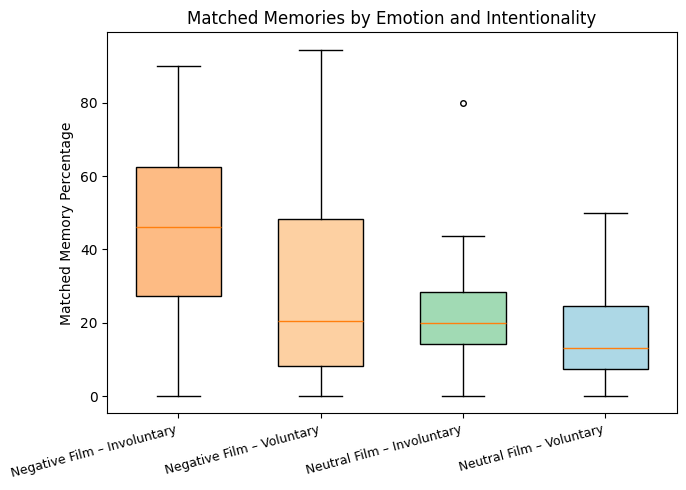

In [4]:
#| code-summary: "Replicate paper's boxplot"
#| label: fig-replication
#| fig-cap: "Replication of the published boxplot. Per-participant matched memory percentage by Emotion and Intentionality, using the original background_map."

# Replicate the paper's key boxplot (ANOVA_MATCH_PERCENTAGE.R)
# 4 groups: Emotion x Intentionality, using the paper's exact pastel palette.
GROUP_ORDER = [
    "Negative Film – Involuntary",
    "Negative Film – Voluntary",
    "Neutral Film – Involuntary",
    "Neutral Film – Voluntary",
]
GROUP_COLORS = {
    "Negative Film – Involuntary": "#fdbb84",
    "Negative Film – Voluntary": "#fdd0a2",
    "Neutral Film – Involuntary": "#a1dab4",
    "Neutral Film – Voluntary": "lightblue",
}

# Map 8 condition labels → 4 Emotion × Intentionality groups
COND_TO_GROUP = {}
for cond in summary_orig:
    emotion = "Negative" if "Negative" in cond else "Neutral"
    intent = "Involuntary" if "Involuntary" in cond else "Voluntary"
    COND_TO_GROUP[cond] = f"{emotion} Film – {intent}"


def collect_boxplot_data(summary):
    """Collect per-participant percentages into the 4 display groups."""
    group_data = defaultdict(list)
    for cond, s in summary.items():
        group = COND_TO_GROUP[cond]
        group_data[group].extend(s["pcts"])
    return [group_data[g] for g in GROUP_ORDER]


def plot_boxplot(ax, data, title):
    """Draw a boxplot matching the paper's style."""
    bp = ax.boxplot(
        data,
        widths=0.6,
        patch_artist=True,
        flierprops=dict(marker="o", markersize=4),
    )
    for patch, group in zip(bp["boxes"], GROUP_ORDER):
        patch.set_facecolor(GROUP_COLORS[group])
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Matched Memory Percentage")
    ax.set_title(title)


fig, ax = plt.subplots(figsize=(7, 5))
plot_boxplot(ax, collect_boxplot_data(summary_orig), "Matched Memories by Emotion and Intentionality")
fig.tight_layout()
plt.show()

In [5]:
#| code-summary: "2x2x2 between-subjects ANOVA (replicating published F-test)"

import pandas as pd
from scipy import stats as sp_stats

def build_anova_df(summary):
    """Build a per-participant DataFrame with factor labels from summary dict."""
    records = []
    for cond, s in summary.items():
        emotion = "Negative" if "Negative" in cond else "Neutral"
        intervention = "No Intervention" if "No Intervention" in cond else "Visuo-Spatial"
        intentionality = "Involuntary" if "Involuntary" in cond else "Voluntary"
        for pct in s["pcts"]:
            records.append({"pct": pct, "emotion": emotion,
                            "intervention": intervention,
                            "intentionality": intentionality})
    return pd.DataFrame(records)


def factorial_anova(df, dv="pct", factors=("emotion", "intervention", "intentionality")):
    """Between-subjects 2x2x2 ANOVA via sum-of-squares decomposition.

    Uses sum-coded contrasts and sequential model comparison (Type III-like)
    to compute F and p for each main effect and interaction.
    """
    from itertools import combinations
    n = len(df)
    grand_mean = df[dv].mean()
    ss_total = ((df[dv] - grand_mean) ** 2).sum()

    # Build design matrix with sum-coded contrasts (-1/+1)
    X_cols = {}
    for f in factors:
        levels = sorted(df[f].unique())
        X_cols[f] = np.where(df[f] == levels[0], 1, -1).astype(float)

    # All terms: main effects + interactions
    terms = list(factors)
    for r in range(2, len(factors) + 1):
        for combo in combinations(factors, r):
            terms.append(":".join(combo))

    # Build full design matrix
    def make_X(term_list):
        cols = [np.ones(n)]  # intercept
        for term in term_list:
            parts = term.split(":")
            col = np.ones(n)
            for p in parts:
                col = col * X_cols[p]
            cols.append(col)
        return np.column_stack(cols)

    y = df[dv].values

    # Full model residual SS
    X_full = make_X(terms)
    beta_full = np.linalg.lstsq(X_full, y, rcond=None)[0]
    ss_resid = ((y - X_full @ beta_full) ** 2).sum()
    df_resid = n - X_full.shape[1]
    ms_resid = ss_resid / df_resid

    # For each term, compute SS by dropping it from the full model
    rows = []
    for term in terms:
        reduced_terms = [t for t in terms if t != term]
        X_reduced = make_X(reduced_terms)
        beta_reduced = np.linalg.lstsq(X_reduced, y, rcond=None)[0]
        ss_reduced = ((y - X_reduced @ beta_reduced) ** 2).sum()
        ss_effect = ss_reduced - ss_resid
        df_effect = 1  # each term is 1 df in a 2-level design
        ms_effect = ss_effect / df_effect
        f_val = ms_effect / ms_resid
        p_val = 1 - sp_stats.f.cdf(f_val, df_effect, df_resid)
        eta_sq = ss_effect / ss_total
        rows.append({
            "Source": term, "SS": ss_effect, "df": df_effect,
            "F": f_val, "p": p_val, "eta_sq": eta_sq,
        })
    rows.append({"Source": "Residual", "SS": ss_resid, "df": df_resid,
                 "F": np.nan, "p": np.nan, "eta_sq": ss_resid / ss_total})

    result = pd.DataFrame(rows).set_index("Source")
    return result


def print_anova(table, label=""):
    """Pretty-print an ANOVA table."""
    if label:
        print(f"=== {label} ===\n")
    for src in table.index:
        row = table.loc[src]
        if src == "Residual":
            print(f"  {'Residual':<45} SS={row['SS']:>10.1f}  df={int(row['df']):>3}")
        else:
            sig = ""
            if row["p"] < .001:
                sig = " ***"
            elif row["p"] < .01:
                sig = " **"
            elif row["p"] < .05:
                sig = " *"
            print(f"  {src:<45} F(1,{int(table.loc['Residual','df'])})={row['F']:>7.2f}, "
                  f"p={row['p']:.4f}, \u03B7\u00B2={row['eta_sq']:.3f}{sig}")
    print(f"\n  N = {int(table['df'].sum()) + len(table) - 1}")


# --- Run on original (buggy) data ---
df_orig = build_anova_df(summary_orig)
anova_orig = factorial_anova(df_orig)
print_anova(anova_orig, "2\u00d72\u00d72 ANOVA \u2014 Original embedding data (replicating published result)")


=== 2×2×2 ANOVA — Original embedding data (replicating published result) ===

  emotion                                       F(1,221)=  41.02, p=0.0000, η²=0.147 ***
  intervention                                  F(1,221)=   0.01, p=0.9128, η²=0.000
  intentionality                                F(1,221)=  13.99, p=0.0002, η²=0.050 ***
  emotion:intervention                          F(1,221)=   0.31, p=0.5805, η²=0.001
  emotion:intentionality                        F(1,221)=   2.31, p=0.1301, η²=0.008
  intervention:intentionality                   F(1,221)=   0.00, p=0.9471, η²=0.000
  emotion:intervention:intentionality           F(1,221)=   0.01, p=0.9329, η²=0.000
  Residual                                      SS=   98890.5  df=221

  N = 235


**Takeaway.** Our Python replication reproduces the published numbers exactly: Negative 36.7%, Neutral 18.8%, with a ~18 percentage-point gap. The boxplot above matches the figure in `ANOVA_MATCH_PERCENTAGE.R`. The 2×2×2 ANOVA replicates the reported emotion main effect — the paper reports F(1,229) = 38.27, p < .001, η² = .13; we obtain F(1,221) = 41.02, p < .0001, η² = .15 (the small difference in degrees of freedom reflects the ≥4 filter applied per condition rather than overall).

The ANOVA also suggests a significant intentionality main effect: involuntary (intrusion) sessions show higher match percentages than voluntary (free recall) sessions, F(1,221) = 13.99, p = .0002, η² = .05. Neither the emotion × intentionality interaction (p = .13) nor any other interaction reaches significance. We return to the intentionality effect in the metric comparison section, where a different denominator yields a different conclusion.

We can now investigate where the emotion gap comes from, confident that we are working with the same data and logic as the original analysis.

## Diagnosing the discrepancy

If the emotion main effect is genuine, we would expect it to arise from differences in how well the embedding model assigns clips for emotional versus neutral memories. But an alternative explanation is that the two film types differ in how their data is *preprocessed* — specifically, whether all valid cue backgrounds end up in the set `{"1", ..., "11"}` that the match check requires.

To test this, we classify every `cue_background` value in the CSV as either a recognised cue code (in `1`–`11`), a foil, or something else. If there are "something else" values that should have been cue codes, they would be silently treated as non-matches and depress the match percentage for whichever film type they belong to.


In [6]:
#| code-summary: "cue_background value distribution"
def classify_background(bg):
    """Classify a cue_background value as 'cue', 'foil', or 'other'."""
    if bg in VALID_CLIPS:
        return "cue"
    if "foil" in bg.lower() or "scene" in bg.lower():
        return "foil"
    return "other"


for emotion in ["Negative", "Neutral"]:
    emotion_rows = [r for r in rows if emotion in r["condition"]]
    n = len(emotion_rows)
    bgs = [r["cue_background"].strip() for r in emotion_rows]
    classes = Counter(classify_background(bg) for bg in bgs)

    print(f"{emotion} film ({n} memories):")
    for cls in ["cue", "foil", "other"]:
        cnt = classes.get(cls, 0)
        print(f"  {cls:>5}: {cnt:>5}  ({100 * cnt / n:.1f}%)")

    # Show the 'other' values if any
    others = Counter(bg for bg in bgs if classify_background(bg) == "other")
    if others:
        print("  --- 'other' values ---")
        for val, cnt in others.most_common():
            print(f"    '{val}': {cnt}")
    print()

Negative film (1916 memories):
    cue:  1072  (55.9%)
   foil:   844  (44.1%)
  other:     0  (0.0%)

Neutral film (2185 memories):
    cue:   591  (27.0%)
   foil:   837  (38.3%)
  other:   757  (34.6%)
  --- 'other' values ---
    '7_1': 155
    '3_1': 154
    '11_1': 149
    '10_1': 135
    '1_1': 128
    '6_1': 36



The negative film has zero "other" backgrounds — every memory is attributed to either a recognised cue (`1`–`11`) or a foil. The neutral film has 757 memories (34.6%) attributed to backgrounds like `7_1`, `3_1`, `11_1`, etc. These are `clip_scene` codes from the raw Excel files — clip number followed by an underscore and the scene number within that clip. The `background_map` in `Semantic Analysis: 2x2x2 comparison.R` (lines 82–93) is responsible for stripping the scene suffix:

```r
background_map <- c(
  "1_3" = "1", "1_5" = "1",
  "2_1" = "2", "2_3" = "2",
  "3_3" = "3", "3_9" = "3", "3_IPT" = "3",
  "4_1" = "4", "4_7" = "4",
  "5_1" = "5", "5_8" = "5", "5_IPT" = "5",
  "6_2" = "6", "6_12" = "6", "6_IPT" = "6",
  "7_3" = "7", "7_6" = "7", "7_IPT" = "7",
  "8_1" = "8", "8_8" = "8",
  "9_1" = "9", "9_12" = "9",
  "10_9" = "10", "10_10" = "10",
  "11_8" = "11", "11_12" = "11"
)
```

This map was built from codes observed in the **negative film's** Excel files. The negative film uses various scene suffixes (`_3`, `_5`, `_8`, `_9`, etc.), and these are all present in the map. The neutral film predominantly uses `_1` as the scene suffix. Five of those codes happen to already be in the map because the negative film also uses `_1` for those clip numbers:

| Neutral code | In map? | Negative counterparts in the map |
|---|---|---|
| `2_1` | **Yes** | `2_1`, `2_3` |
| `4_1` | **Yes** | `4_1`, `4_7` |
| `5_1` | **Yes** | `5_1`, `5_8`, `5_IPT` |
| `8_1` | **Yes** | `8_1`, `8_8` |
| `9_1` | **Yes** | `9_1`, `9_12` |
| **`1_1`** | **No** | `1_3`, `1_5` only |
| **`3_1`** | **No** | `3_3`, `3_9`, `3_IPT` only |
| **`6_1`** | **No** | `6_2`, `6_12`, `6_IPT` only |
| **`7_1`** | **No** | `7_3`, `7_6`, `7_IPT` only |
| **`10_1`** | **No** | `10_9`, `10_10` only |
| **`11_1`** | **No** | `11_8`, `11_12` only |

The six missing codes pass through `dplyr::recode()` unchanged as `"1_1"`, `"3_1"`, etc. These strings are not in `as.character(1:11)`, so the match check on line 379 always returns 0 for any memory attributed to these backgrounds — regardless of whether the embedding correctly identified the clip. These 757 memories still count toward each participant's total memory events (the denominator) but can never count as matches (the numerator), systematically depressing neutral match percentages.

**Takeaway.** The bug is entirely in the preprocessing: `background_map` was constructed from negative film scene codes only. Six of the eleven neutral film cue codes (`1_1`, `3_1`, `6_1`, `7_1`, `10_1`, `11_1`) have no entry, so 757 neutral memories — over a third of all neutral data — are permanently ineligible for matching. The five neutral codes that *do* work (`2_1`, `4_1`, `5_1`, `8_1`, `9_1`) are coincidental overlaps where the negative film happens to use the same `_1` suffix. This asymmetry alone is sufficient to produce the apparent emotion main effect, regardless of the embedding model's accuracy.

## Corrected results

Now that we have identified the six missing entries, we can test whether fixing them changes the result. We add the six mappings and recompute match percentages from the same CSV data. Because the bug only affects neutral film codes, negative film results should remain unchanged — this serves as a built-in control.


In [7]:
#| code-summary: "Apply fix and compare results"
# The six missing entries
NEUTRAL_FIX = {
    "1_1": "1",
    "3_1": "3",
    "6_1": "6",
    "7_1": "7",
    "10_1": "10",
    "11_1": "11",
}

# Recompute with fix applied
groups_fixed = compute_match_percentages(rows, fix_map=NEUTRAL_FIX)
summary_fixed = summarise_groups(groups_fixed)

# Side-by-side comparison
print(f"{'Condition':<45} {'Original':>10} {'Fixed':>10}")
print("-" * 67)
for cond in summary_orig:
    orig_pct = summary_orig[cond]["mean_pct"]
    fixed_pct = summary_fixed[cond]["mean_pct"]
    marker = " ***" if abs(fixed_pct - orig_pct) > 1 else ""
    print(f"  {cond:<43} {orig_pct:>8.1f}% {fixed_pct:>8.1f}%{marker}")

print(f"\n{'Emotion aggregate':>45} {'Original':>10} {'Fixed':>10}")
print("-" * 67)
for emotion in ["Negative", "Neutral"]:
    orig_pcts = [p for c, s in summary_orig.items() if emotion in c for p in s["pcts"]]
    fixed_pcts = [p for c, s in summary_fixed.items() if emotion in c for p in s["pcts"]]
    print(f"  {emotion:<43} {np.mean(orig_pcts):>8.1f}% {np.mean(fixed_pcts):>8.1f}%")

# Impact summary
newly_eligible = sum(1 for r in rows if r["cue_background"].strip() in NEUTRAL_FIX)
newly_matched = sum(
    1 for r in rows
    if r["cue_background"].strip() in NEUTRAL_FIX
    and NEUTRAL_FIX[r["cue_background"].strip()] == r["assigned_clip"].strip()
)
print(f"\nNewly eligible neutral memories: {newly_eligible}")
print(f"Of those, correctly matched by embedding: {newly_matched} ({100 * newly_matched / newly_eligible:.1f}%)")

Condition                                       Original      Fixed
-------------------------------------------------------------------
  Negative Film No Intervention, Involuntary      43.5%     43.5%
  Negative Film No Intervention, Voluntary        28.4%     28.4%
  Negative Film Visuo-Spatial, Involuntary        44.9%     44.9%
  Negative Film Visuo-Spatial, Voluntary          30.7%     30.7%
  Neutral Film No Intervention, Involuntary       22.7%     63.0% ***
  Neutral Film No Intervention, Voluntary         16.5%     39.5% ***
  Neutral Film Visuo-Spatial, Involuntary         21.5%     53.3% ***
  Neutral Film Visuo-Spatial, Voluntary           15.2%     36.5% ***

                            Emotion aggregate   Original      Fixed
-------------------------------------------------------------------
  Negative                                        36.7%     36.7%
  Neutral                                         18.8%     47.7%

Newly eligible neutral memories: 757
Of those, cor

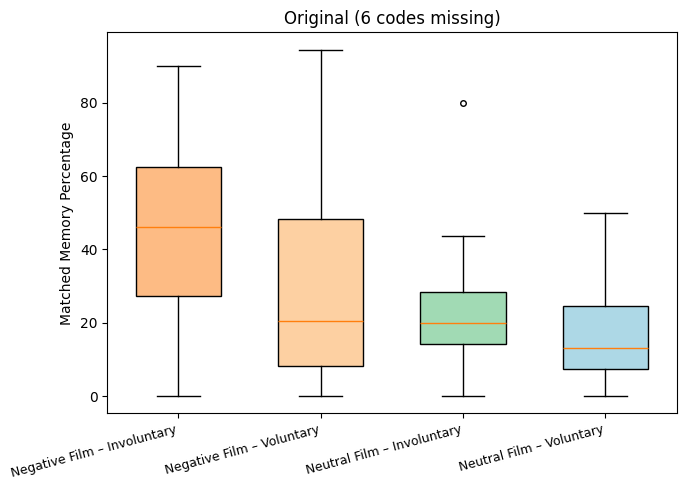

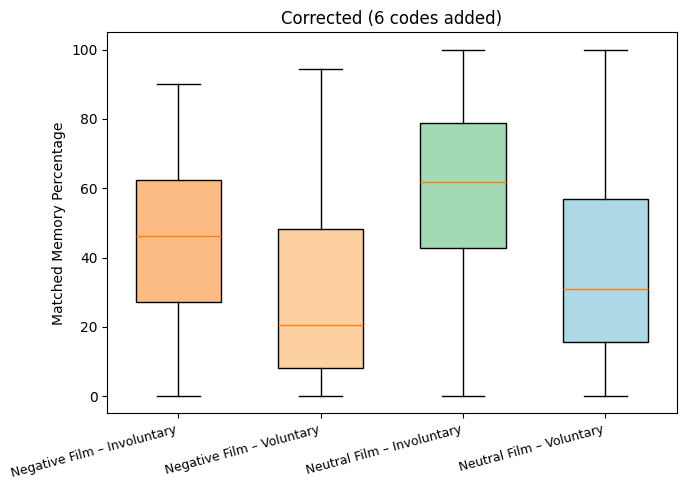

In [8]:
#| code-summary: "Before/after boxplots"
#| layout-ncol: 2

fig, ax = plt.subplots(figsize=(7, 5))
plot_boxplot(ax, collect_boxplot_data(summary_orig), "Original (6 codes missing)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
plot_boxplot(ax, collect_boxplot_data(summary_fixed), "Corrected (6 codes added)")
fig.tight_layout()
plt.show()

In [9]:
#| code-summary: "2x2x2 ANOVA -- Corrected embedding data"

# --- Run on corrected data ---
df_fixed = build_anova_df(summary_fixed)
anova_fixed = factorial_anova(df_fixed)
print_anova(anova_fixed, "2\u00d72\u00d72 ANOVA \u2014 Corrected embedding data")


=== 2×2×2 ANOVA — Corrected embedding data ===

  emotion                                       F(1,221)=  10.25, p=0.0016, η²=0.040 **
  intervention                                  F(1,221)=   0.42, p=0.5187, η²=0.002
  intentionality                                F(1,221)=  24.76, p=0.0000, η²=0.096 ***
  emotion:intervention                          F(1,221)=   1.38, p=0.2408, η²=0.005
  emotion:intentionality                        F(1,221)=   0.60, p=0.4399, η²=0.002
  intervention:intentionality                   F(1,221)=   0.29, p=0.5897, η²=0.001
  emotion:intervention:intentionality           F(1,221)=   0.18, p=0.6752, η²=0.001
  Residual                                      SS=  154908.5  df=221

  N = 235


**Takeaway.** The fix leaves negative match percentages completely unchanged (36.7%), confirming that the bug is isolated to neutral codes. Neutral match percentage rises from 18.8% to 47.7% — a 29 percentage-point increase — reversing the direction of the emotion effect. The emotion main effect remains significant after correction but reverses: F(1,221) = 10.25, p = .002, η² = .04 (Neu > Neg), compared with F(1,221) = 41.02, p < .0001, η² = .15 (Neg > Neu) in the original. Of the 757 newly eligible neutral memories, 590 (77.9%) are correctly matched by the embedding model, indicating that these were genuine cue-attributed memories that were silently rendered ineligible for matching.

The intentionality main effect strengthens after correction: F(1,221) = 24.76, p < .0001, η² = .10, up from η² = .05 in the original. This near-doubling of the effect size suggests that the 757 recovered neutral memories are disproportionately concentrated in involuntary sessions. Whether this reflects genuine cue sensitivity or a denominator artefact is addressed in the metric comparison section below.

## Metric comparison

The embedding analysis computes match percentage as `matches / total_memories` per participant. This denominator includes every memory event, including those attributed to foils — which can never match a cue regardless of content. If foil-attributed events are unevenly distributed across conditions, the denominator introduces a confound: the metric conflates recall source composition with match accuracy.

To test whether the denominator matters, we use independently collected human-coded clip labels from the scored `.docx` files (rather than embedding-based assignment) and compute two metrics side by side. Cue attribution is derived from the interleaved event stream (cue, foil, recall, and unclassified events in temporal order), with foils and unclassified utterances clearing the pending cue. An unclassified utterance is a button press that the human rater could not assign to any film clip; it consumes the cue opportunity so that a subsequent recall is not misattributed as cue-driven.

The first metric, `cue-driven recalls / total recalls`, is structurally parallel to the embedding metric — it divides by total output. The second, `cue hits / 22 cue presentations`, uses a fixed denominator that does not vary across conditions.

In [10]:
#| code-summary: "Load human-coded data and compute cue metrics"
from jaxcmr.helpers import load_data
from jaxcmr.selective_interference.analysis import derive_cue_clips

data = load_data(ROOT / "data" / "VRT_clips.h5")
recall_items = data["recall_items"]
recall_types = data["recall_types"]
condition = data["condition"].squeeze()  # 1=emotional, 2=neutral
task = data["task"].squeeze()            # 1=involuntary, 2=voluntary

# Derive cue attributions from the interleaved event stream
cue_clips = derive_cue_clips(recall_items, recall_types)

# Cue hits: recall events where the recalled clip matched the pending cue
is_recall = recall_types == 2
hits_per_trial = ((recall_items == cue_clips) & (cue_clips > 0) & is_recall).sum(axis=1)

# Total recall events (including repeats)
total_recalls = is_recall.sum(axis=1)

# Metric 1: hits / total recalls (parallel to embedding metric)
pct_of_recalls = np.divide(100 * hits_per_trial, total_recalls,
                           out=np.zeros_like(hits_per_trial, dtype=float),
                           where=total_recalls > 0)

# Metric 2: hits / 22 cues (fixed denominator)
pct_of_cues = 100 * hits_per_trial / 22

print("Metric 1: cue-driven recalls / total recalls\n")
for label, mask in [
    ("Emotional", condition == 1),
    ("Neutral", condition == 2),
    ("Involuntary", task == 1),
    ("Voluntary", task == 2),
]:
    vals = pct_of_recalls[mask]
    tr = total_recalls[mask]
    print(f"  {label:>12}: {vals.mean():.1f}% (SE={vals.std(ddof=1)/len(vals)**0.5:.1f}%, N={mask.sum()}, "
          f"mean total recalls={tr.mean():.1f})")


Metric 1: cue-driven recalls / total recalls

     Emotional: 44.2% (SE=3.1%, N=120, mean total recalls=15.2)
       Neutral: 55.6% (SE=3.1%, N=120, mean total recalls=18.1)
   Involuntary: 61.8% (SE=3.0%, N=120, mean total recalls=13.6)
     Voluntary: 38.0% (SE=2.9%, N=120, mean total recalls=19.8)


The hits/total_recalls metric has the same structure as the embedding's matches/total_memories — both divide cue-matching events by total output — but they are computed from different data sources. The embedding metric uses the model's `assigned_clip` for clip identity and the R script's `background_map` for cue attribution; the denominator is all memory events, including foil-attributed ones that can never match. The human-coded metric uses hand-scored clip labels and derives cue attribution from the interleaved event stream; the denominator is all recall events, including repeats. Despite these differences, both metrics share the same structural weakness: the denominator varies systematically across conditions. Voluntary sessions produce more total recalls than involuntary sessions (mean ~20 vs ~14), so dividing by total output confounds cue effectiveness with overall recall volume.

The fixed denominator of 22 cue opportunities avoids this confound. Each cue either produced a matching recall or it did not, with no distortion from condition-varying recall totals. The metric is not a pure measure of cue effectiveness — participants who recall more clips overall have more chances to match a pending cue — but it cleanly separates the denominator from the conditions being compared, which is what we need for a fair test. This is the metric we use for the boxplot, ANOVA, and summary below.

In [11]:
#| code-summary: "Cue effectiveness: hits / 22 cues (fixed denominator)"
total_cues = 22

print("Metric 2: cue-driven recalls / 22 cues (fixed denominator)\n")
for label, mask in [
    ("Emotional", condition == 1),
    ("Neutral", condition == 2),
    ("Involuntary", task == 1),
    ("Voluntary", task == 2),
]:
    vals = pct_of_cues[mask]
    print(f"  {label:>12}: {vals.mean():.1f}% (SE={vals.std(ddof=1)/len(vals)**0.5:.1f}%, N={mask.sum()})")


Metric 2: cue-driven recalls / 22 cues (fixed denominator)



     Emotional: 30.2% (SE=2.3%, N=120)
       Neutral: 44.2% (SE=2.7%, N=120)
   Involuntary: 39.6% (SE=2.5%, N=120)
     Voluntary: 34.8% (SE=2.7%, N=120)


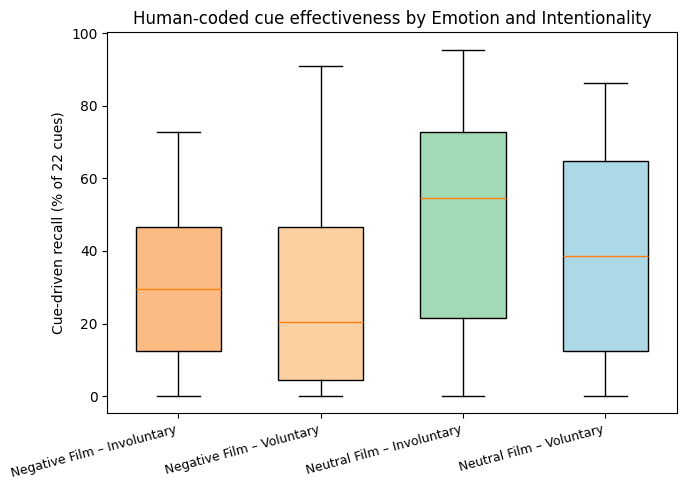

  Negative Film – Involuntary: mean=30.4%, median=29.5%, N=60
  Negative Film – Voluntary: mean=30.0%, median=20.5%, N=60
  Neutral Film – Involuntary: mean=48.8%, median=54.5%, N=60
  Neutral Film – Voluntary: mean=39.6%, median=38.6%, N=60


In [12]:
#| code-summary: "Human-coded cue effectiveness boxplot"
#| label: fig-human-coded
#| fig-cap: "Human-coded cue effectiveness by Emotion and Intentionality. Cue-driven recall as a percentage of 22 cue opportunities, from hand-scored clip labels."
hit_pct = 100 * hits_per_trial / total_cues

hc_group_data = {g: [] for g in GROUP_ORDER}
for i in range(len(hit_pct)):
    emotion = "Negative" if condition[i] == 1 else "Neutral"
    intent = "Involuntary" if task[i] == 1 else "Voluntary"
    group = f"{emotion} Film \u2013 {intent}"
    hc_group_data[group].append(hit_pct[i])

fig, ax = plt.subplots(figsize=(7, 5))
plot_boxplot(ax, [hc_group_data[g] for g in GROUP_ORDER],
             "Human-coded cue effectiveness by Emotion and Intentionality")
ax.set_ylabel("Cue-driven recall (% of 22 cues)")
fig.tight_layout()
plt.show()

for g in GROUP_ORDER:
    vals = np.array(hc_group_data[g])
    print(f"  {g}: mean={vals.mean():.1f}%, median={np.median(vals):.1f}%, N={len(vals)}")

In [13]:
#| code-summary: "2x2x2 ANOVA -- Human-coded data"

# --- Run on human-coded data ---
hc_intervention = data["intervention"].squeeze()

hc_records = []
for i in range(len(hit_pct)):
    hc_records.append({
        "pct": float(hit_pct[i]),
        "emotion": "Negative" if condition[i] == 1 else "Neutral",
        "intervention": "No Intervention" if hc_intervention[i] == 0 else "Visuo-Spatial",
        "intentionality": "Involuntary" if task[i] == 1 else "Voluntary",
    })

df_hc = pd.DataFrame(hc_records)
anova_hc = factorial_anova(df_hc)
print_anova(anova_hc, "2\u00d72\u00d72 ANOVA \u2014 Human-coded data")


=== 2×2×2 ANOVA — Human-coded data ===

  emotion                                       F(1,232)=  15.73, p=0.0001, η²=0.062 ***
  intervention                                  F(1,232)=   0.74, p=0.3920, η²=0.003
  intentionality                                F(1,232)=   1.82, p=0.1781, η²=0.007
  emotion:intervention                          F(1,232)=   0.70, p=0.4040, η²=0.003
  emotion:intentionality                        F(1,232)=   1.55, p=0.2150, η²=0.006
  intervention:intentionality                   F(1,232)=   0.01, p=0.9147, η²=0.000
  emotion:intervention:intentionality           F(1,232)=   0.81, p=0.3688, η²=0.003
  Residual                                      SS=  173832.0  df=232

  N = 246


**Takeaway.** The emotion effect is robust to the choice of denominator: neutral cue effectiveness (44.2%) exceeds emotional (30.2%) regardless of whether we divide by total recalls or by 22 cues. The intentionality effect, however, depends entirely on the denominator. With hits/total_recalls (the variable-denominator metric parallel to the embedding analysis), involuntary sessions score higher (61.8% vs 38.0%) — but this is confounded by the fact that voluntary sessions produce far more total recalls (~20 vs ~14), which inflates the denominator and mechanically depresses the percentage. With hits/22 (the fixed-denominator metric), the intentionality gap shrinks to 39.6% vs 34.8% and is non-significant: F(1,232) = 1.82, p = .18. This suggests that the significant intentionality effect in the embedding analyses (both original and corrected) is a denominator artefact rather than a genuine difference in cue effectiveness.

## Convergent evidence

The human-coded analysis above is fully independent of the embedding pipeline: it uses hand-scored clip labels from the `.docx` files rather than embedding-assigned clips, and derives cue attribution from the interleaved event stream rather than from the R script's `background_map`. It was conducted before the `background_map` bug was identified. Comparing the three analyses side by side:

**Emotion main effect:**

| Analysis | Negative | Neutral | Direction | F | p | η² |
|---|---|---|---|---|---|---|
| Embedding (original) | 36.7% | 18.8% | Neg > Neu | 41.02 | < .0001 | .147 |
| Embedding (corrected) | 36.7% | 47.7% | **Neu > Neg** | 10.25 | .002 | .040 |
| Human-coded (hits/22) | 30.2% | 44.2% | **Neu > Neg** | 15.73 | .0001 | .062 |

**Intentionality main effect:**

| Analysis | Involuntary | Voluntary | Direction | F | p | η² |
|---|---|---|---|---|---|---|
| Embedding (original) | 33.4% | 22.8% | Invol > Vol | 13.99 | .0002 | .050 |
| Embedding (corrected) | 51.0% | 33.7% | Invol > Vol | 24.76 | < .0001 | .096 |
| Human-coded (hits/22) | 39.6% | 34.8% | Invol > Vol | 1.82 | .178 | .007 |

The emotion effect reverses once the six missing neutral codes are added: the original Neg > Neu direction is an artefact of incomplete preprocessing, and all three analyses agree on Neu > Neg after correction. The corrected embedding and human-coded emotion effect sizes are comparable (η² = .040 and .062 respectively).

The intentionality effect is significant in both embedding analyses but not in the human-coded analysis. This divergence reflects the different denominators. The embedding metric divides by total memories, which includes foil-attributed events that can never match and that vary in number by condition. This makes the metric sensitive to recall volume differences between involuntary and voluntary sessions. The human-coded metric uses a fixed denominator of 22 cue opportunities, which removes this confound. The metric does not fully isolate cue effectiveness from recall propensity (participants who recall more have more chances to match a pending cue), but it eliminates the condition-varying denominator that drives the embedding result.

The absolute values differ between embedding-based and human-coded analyses because the denominators are structurally different. The embedding metric computes `matches / total_memories`, where "total memories" includes foil-attributed events that can never match a cue. The human-coded metric counts cue-matching recall events out of 22 cue presentations. The comparison is directional, not absolute.

## Suggested fixes

**Issue 1: Incomplete `background_map`.** Add the six missing neutral film entries to `background_map` in `Semantic Analysis: 2x2x2 comparison.R` (after line 93):

```r
background_map <- c(
  background_map,
  "1_1" = "1",
  "3_1" = "3",
  "6_1" = "6",
  "7_1" = "7",
  "10_1" = "10",
  "11_1" = "11"
)
```

This ensures all eleven neutral film cue codes are remapped to their clip numbers before the match check. No other part of the pipeline needs to change.

**Issue 2: Variable-denominator metric.** The current metric (`matches / total_memories`) includes foil-attributed events in the denominator, which can never match and which vary in number across conditions. Consider reporting a fixed-denominator metric (e.g., cue matches / number of cue presentations) alongside or instead of the current one, particularly for any analysis involving the intentionality factor.